In [9]:
import sys
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from app.image_processing import process_leaf_image, preprocess_image, extract_leaf_mask, extract_disease_mask

In [10]:
# Main dataset folder
dataset_path = r"C:\Users\Taruni\Desktop\My Projects\quantitative-botanical-reasoning\dataset"

# Selected classes for the assignment
selected_classes = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Late_blight"
]

# Store image paths for each class
image_paths = {}

for class_name in selected_classes:
    class_folder = os.path.join(dataset_path, class_name)
    
    # collect jpg, jpeg, png files
    paths = glob.glob(os.path.join(class_folder, "*.jpg"))
    paths += glob.glob(os.path.join(class_folder, "*.jpeg"))
    paths += glob.glob(os.path.join(class_folder, "*.png"))
    
    image_paths[class_name] = paths
    print(f"{class_name}: {len(paths)} images found")

Tomato_healthy: 1591 images found
Tomato_Early_blight: 1000 images found
Tomato_Late_blight: 1909 images found


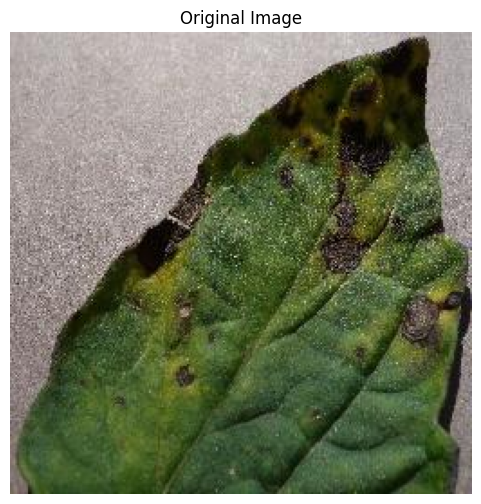

In [11]:
sample_path = image_paths["Tomato_Early_blight"][0]
img = cv2.imread(sample_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

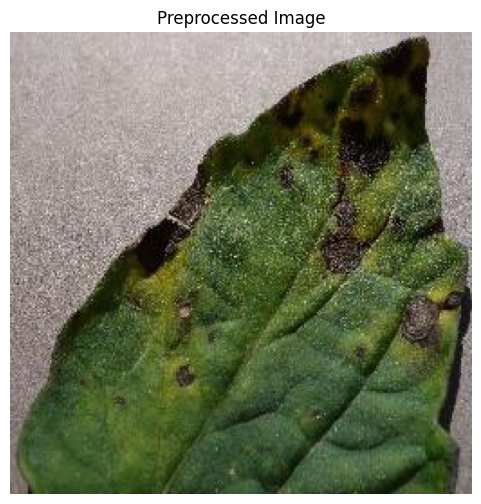

In [12]:
img_processed = preprocess_image(img)
img_processed_rgb = cv2.cvtColor(img_processed, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_processed_rgb)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

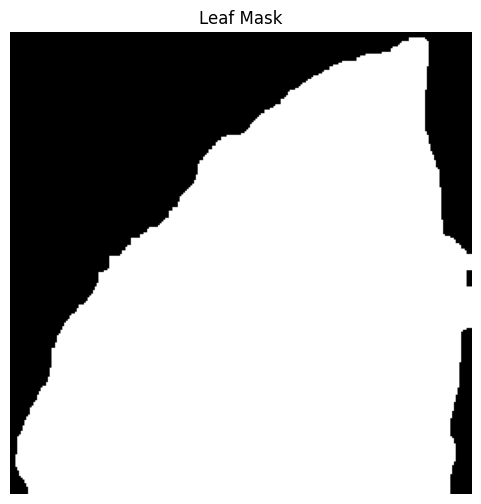

In [13]:
leaf_mask = extract_leaf_mask(img_processed)

plt.figure(figsize=(6, 6))
plt.imshow(leaf_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")
plt.show()

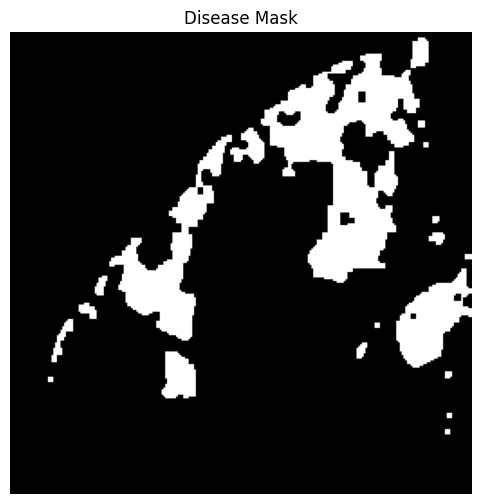

In [14]:
disease_mask = extract_disease_mask(img_processed, leaf_mask)

plt.figure(figsize=(6, 6))
plt.imshow(disease_mask, cmap="gray")
plt.title("Disease Mask")
plt.axis("off")
plt.show()

In [15]:
results = process_leaf_image(img)

print("Leaf Area       :", results["leaf_area"], "pixels")
print("Diseased Area   :", results["disease_area"], "pixels")
print("Healthy Area    :", results["healthy_area"], "pixels")
print("Disease Percent :", f"{results['disease_percentage']:.2f}%")
print("Severity        :", results["severity"])

Leaf Area       : 43250 pixels
Diseased Area   : 3656 pixels
Healthy Area    : 39594 pixels
Disease Percent : 8.45%
Severity        : Mild


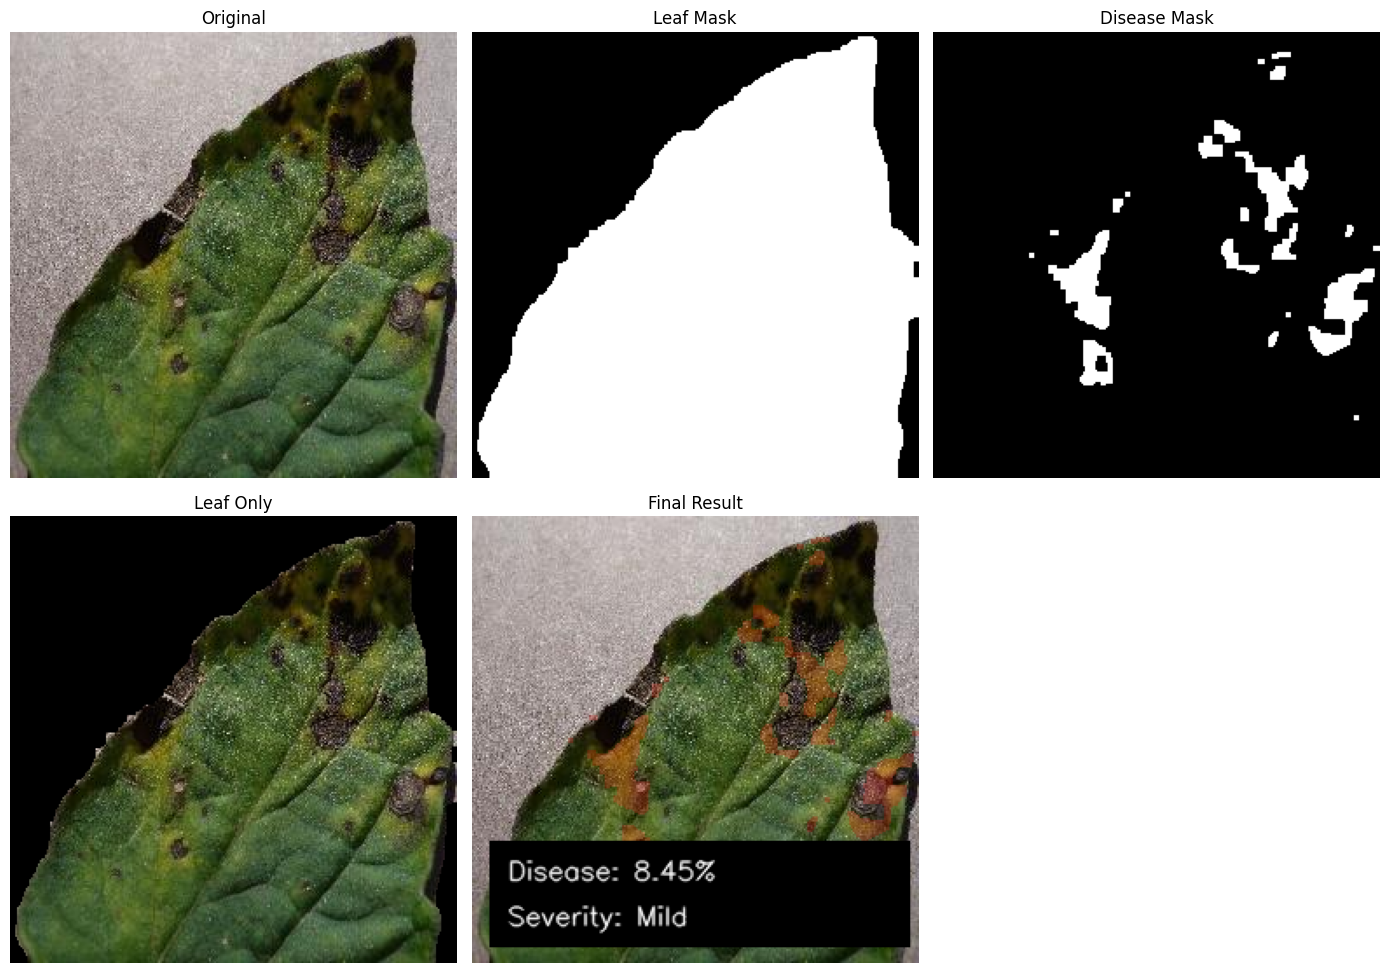

In [16]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(results["original"])
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(results["leaf_mask"], cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(results["disease_mask"], cmap="gray")
plt.title("Disease Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(results["leaf_only"])
plt.title("Leaf Only")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(results["final_result"])
plt.title("Final Result")
plt.axis("off")

plt.tight_layout()
plt.show()

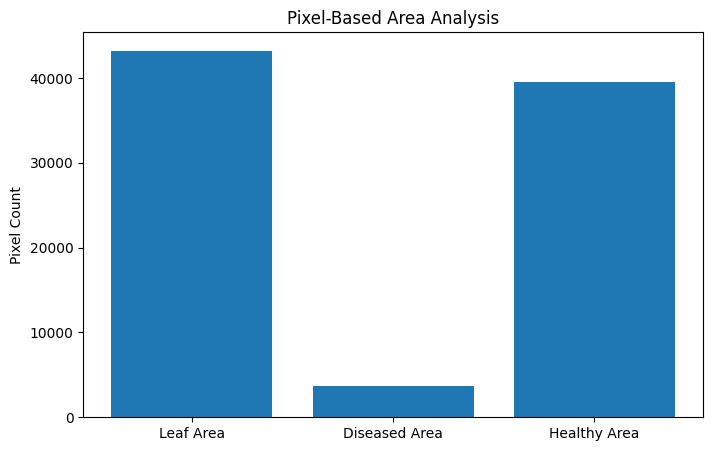

In [17]:
labels = ["Leaf Area", "Diseased Area", "Healthy Area"]
values = [results["leaf_area"], results["disease_area"], results["healthy_area"]]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Pixel-Based Area Analysis")
plt.ylabel("Pixel Count")
plt.show()

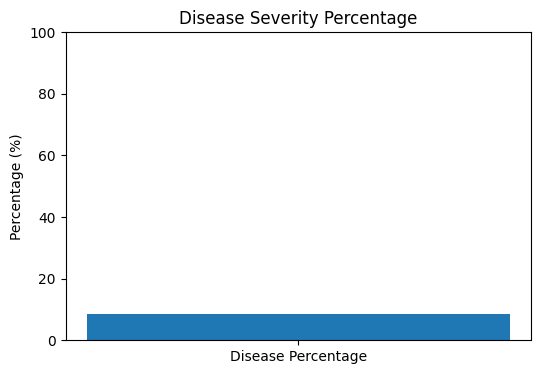

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(["Disease Percentage"], [results["disease_percentage"]])
plt.ylim(0, 100)
plt.title("Disease Severity Percentage")
plt.ylabel("Percentage (%)")
plt.show()

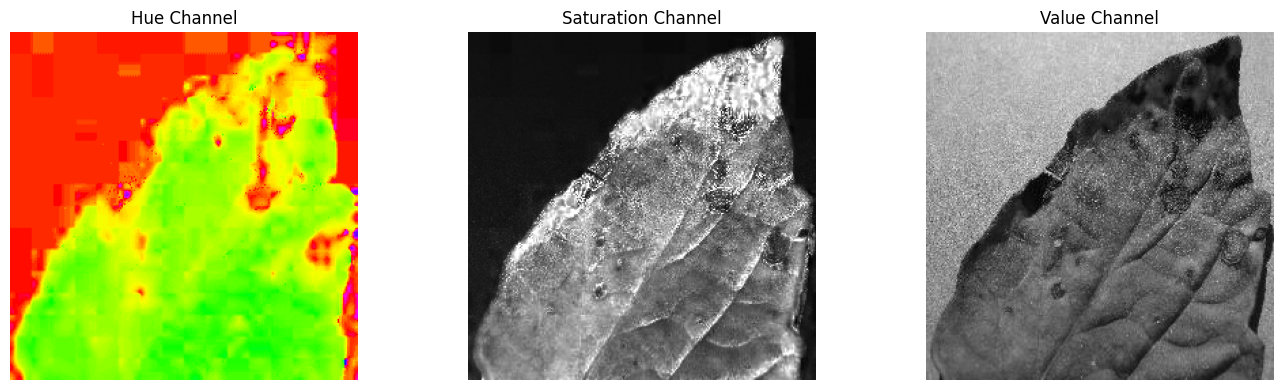

In [19]:
hsv = cv2.cvtColor(img_processed, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(h, cmap="hsv")
plt.title("Hue Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(s, cmap="gray")
plt.title("Saturation Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(v, cmap="gray")
plt.title("Value Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
print("Interpretation:")
print(
    f"The image-processing pipeline detected the leaf region first, then segmented suspected "
    f"diseased regions inside the leaf. The computed disease severity was "
    f"{results['disease_percentage']:.2f}%, which corresponds to a severity level of "
    f"'{results['severity']}'."
)

Interpretation:
The image-processing pipeline detected the leaf region first, then segmented suspected diseased regions inside the leaf. The computed disease severity was 8.45%, which corresponds to a severity level of 'Mild'.
